Google just released [Gemma 4](https://blog.google/innovation-and-ai/technology/developers-tools/gemma-4/) — open-weight models (Apache 2.0) available directly through the Gemini API. Same SDK, same API key — just change the model name.

| Model | Type | Size |
|-------|------|------|
| `gemini-3.1-pro-preview` | Closed | Large |
| `gemini-3.1-flash-lite-preview` | Closed | Small |
| `gemma-4-31b-it` | Open | 31B dense |
| `gemma-4-26b-a4b-it` | Open | 26B MoE (4B active) |

In [49]:
import os, json, re, time, asyncio
from google import genai
from google.genai import types
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

client = genai.Client(api_key=os.environ['GEMINI_API_KEY'])

MODELS = [
    "gemini-3.1-pro-preview",
    "gemini-3.1-flash-lite-preview",
    "gemma-4-31b-it",
    "gemma-4-26b-a4b-it",
]
SHORT = {m: m for m in MODELS}

%config InlineBackend.figure_format = 'retina'

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


## Available Models

In [50]:
rows = []
for m in client.models.list():
    if any(k in m.name.lower() for k in ['gemma-4', 'gemini-3']):
        rows.append({"Model": m.name, "Input": f"{m.input_token_limit:,}", "Output": f"{m.output_token_limit:,}"})
pd.DataFrame(rows).style.hide(axis='index')

Model,Input,Output
models/gemma-4-26b-a4b-it,"262,144","32,768"
models/gemma-4-31b-it,"262,144","32,768"
models/gemini-3-pro-preview,"1,048,576","65,536"
models/gemini-3-flash-preview,"1,048,576","65,536"
models/gemini-3.1-pro-preview,"1,048,576","65,536"
models/gemini-3.1-pro-preview-customtools,"1,048,576","65,536"
models/gemini-3.1-flash-lite-preview,"1,048,576","65,536"
models/gemini-3-pro-image-preview,"131,072","32,768"
models/gemini-3.1-flash-image-preview,"65,536","65,536"
models/gemini-3.1-flash-live-preview,"131,072","65,536"


## Async Comparison Helper

Calling 4 models sequentially is slow (Gemma can take 60-100s). We call them **all in parallel** using `client.aio`.

In [ ]:
async def _call_one(model, parts, config=None):
    t0 = time.time()
    try:
        kw = {"model": model, "contents": parts}
        if config:
            kw["config"] = config
        resp = await client.aio.models.generate_content(**kw)
        dt = time.time() - t0
        u = resp.usage_metadata
        return model, {
            "response": resp.text or "[empty]",
            "time_s": dt, "time": f"{dt:.1f}s",
            "in_tok": u.prompt_token_count if u else 0,
            "out_tok": u.candidates_token_count if u else 0,
        }
    except Exception as e:
        return model, {"response": f"**Error**: {e}", "time_s":0, "time":"err", "in_tok":0, "out_tok":0}


def compare(prompt, images=None, display_images=True, config=None):
    """Run prompt on all models in parallel."""
    if images and display_images:
        n = len(images)
        fig, axes = plt.subplots(1, n, figsize=(4*n, 3))
        if n == 1: axes = [axes]
        for ax, img in zip(axes, images):
            ax.imshow(img); ax.axis('off')
        plt.tight_layout(); plt.show()

    parts = list(images or []) + [prompt]
    t0 = time.time()

    async def _go():
        return dict(await asyncio.gather(*[_call_one(m, parts, config) for m in MODELS]))

    try:
        loop = asyncio.get_running_loop()
        import nest_asyncio; nest_asyncio.apply()
        results = loop.run_until_complete(_go())
    except RuntimeError:
        results = asyncio.run(_go())

    wall = time.time() - t0
    seq = sum(r['time_s'] for r in results.values())

    for model, r in results.items():
        text = r['response'][:2000] + "\n*[truncated]*" if len(r['response']) > 2000 else r['response']
        display(Markdown(f"**{SHORT[model]}** &nbsp;|&nbsp; {r['time']} &nbsp;|&nbsp; {r['out_tok']} tok"))
        display(Markdown(text))

    print(f"\n\u23f1 Wall: {wall:.1f}s (parallel) vs {seq:.1f}s (sequential would be)")
    return results

## Task 1: Scene Understanding

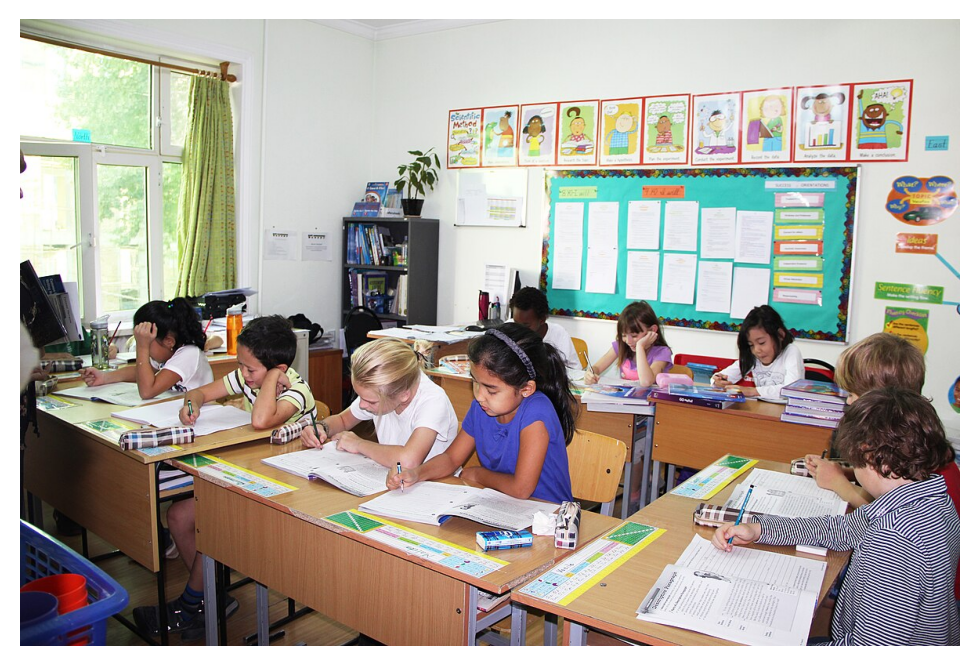

**gemini-3.1-pro-preview** &nbsp;|&nbsp; 10.8s &nbsp;|&nbsp; 64 tok

In a brightly lit classroom, several young students are sitting at wooden desks, diligently focused on writing and reading in their open notebooks. The room is filled with educational objects, including colorful learning posters lining the upper wall, a large green bulletin board displaying papers, a bookshelf, and typical desk supplies like pencils and pencil cases.

**gemini-3.1-flash-lite-preview** &nbsp;|&nbsp; 3.0s &nbsp;|&nbsp; 48 tok

This image shows a classroom of elementary school children sitting at their wooden desks, diligently working on their assignments. The room is filled with learning materials, including educational posters on the walls, a bookshelf, and a large bulletin board displaying classroom work.

**gemma-4-31b-it** &nbsp;|&nbsp; 12.2s &nbsp;|&nbsp; 43 tok

Several students are sitting at wooden desks in a bright classroom, focused on completing assignments or taking a test. The room is filled with school supplies like notebooks and pens, and the walls are decorated with colorful educational posters.

**gemma-4-26b-a4b-it** &nbsp;|&nbsp; 16.8s &nbsp;|&nbsp; 53 tok

A group of young students are sitting at their desks in a bright classroom, focused on reading and writing in their workbooks. The room is filled with educational items, including colorful posters on the walls, bookshelves, and various supplies like pens, paper, and notebooks.


⏱ Wall: 16.8s (parallel) vs 42.8s (sequential would be)


In [52]:
results_scene = compare(
    "Describe this image in 2-3 sentences. What is happening and what objects do you see?",
    images=[Image.open("classroom.jpg")],
)

## Task 2: Chart Analysis

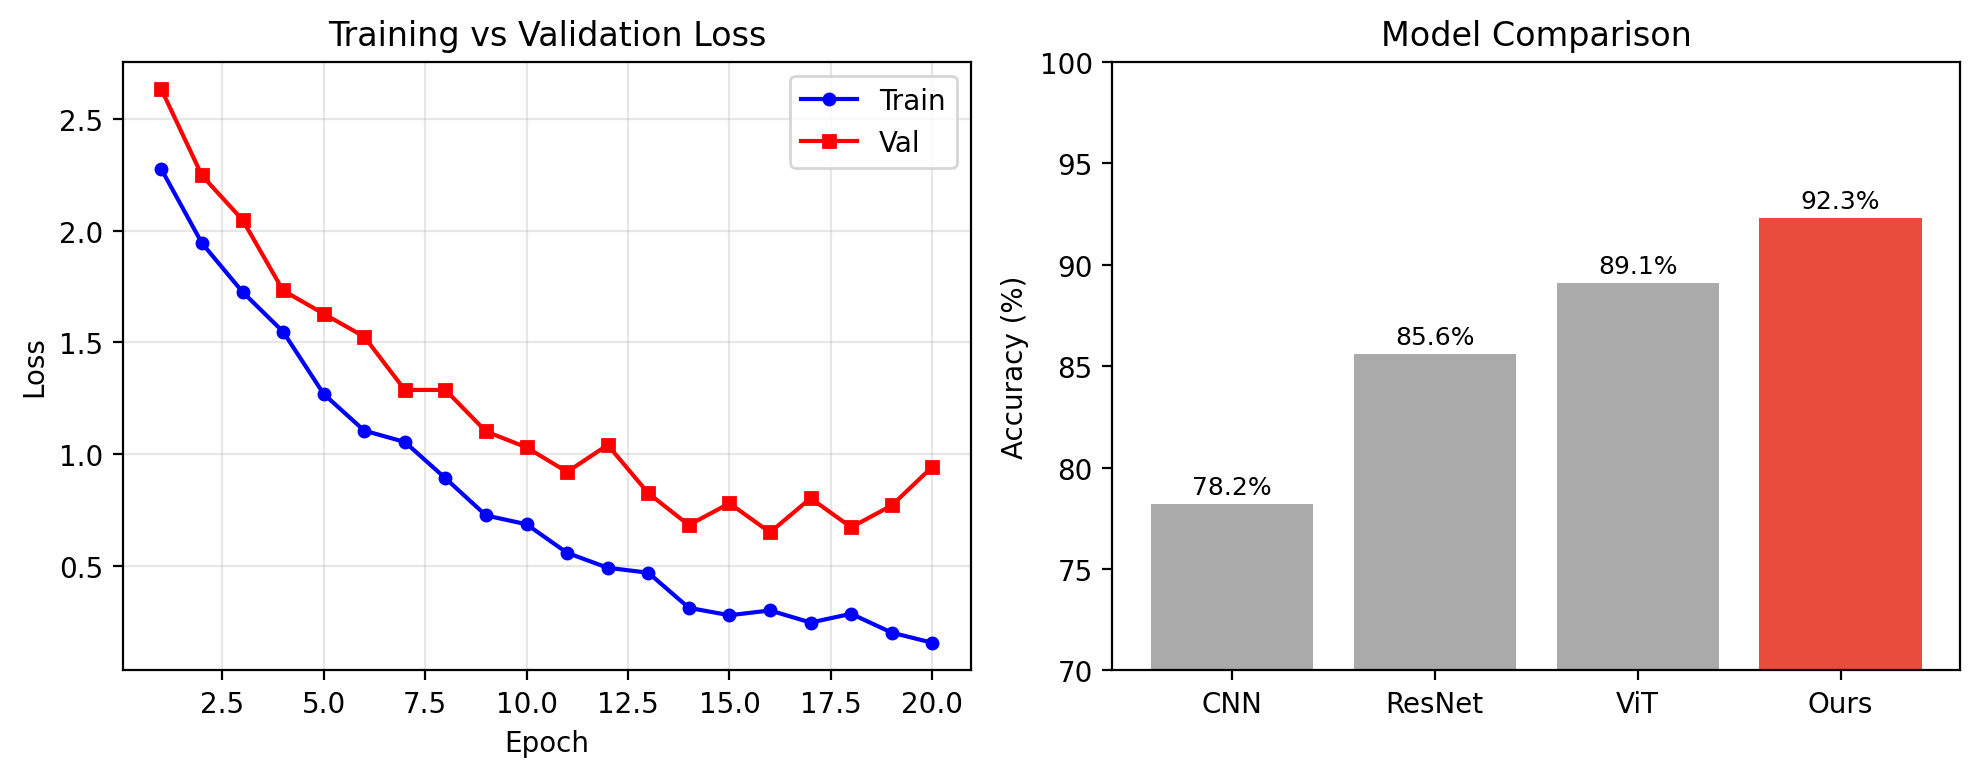

In [53]:
np.random.seed(42)
epochs = np.arange(1, 21)
train_loss = 2.5 * np.exp(-0.15 * epochs) + 0.1 + np.random.normal(0, 0.05, 20)
val_loss = 2.5 * np.exp(-0.12 * epochs) + 0.3 + np.random.normal(0, 0.08, 20)
val_loss[14:] += np.linspace(0, 0.4, 6)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(epochs, train_loss, 'b-o', label='Train', ms=4)
ax1.plot(epochs, val_loss, 'r-s', label='Val', ms=4)
ax1.set(xlabel='Epoch', ylabel='Loss', title='Training vs Validation Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

bars = ['CNN', 'ResNet', 'ViT', 'Ours']
acc = [78.2, 85.6, 89.1, 92.3]
ax2.bar(bars, acc, color=['#aaa','#aaa','#aaa','#e74c3c'])
ax2.set(ylabel='Accuracy (%)', title='Model Comparison', ylim=(70,100))
for i, v in enumerate(acc): ax2.text(i, v+0.5, f'{v}%', ha='center', fontsize=9)
plt.tight_layout()
fig.savefig('/tmp/research_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [54]:
results_chart = compare(
    """Analyze these two plots concisely:
1. Left: what does it show and at which epoch does overfitting begin?
2. Right: which model is best and by how much over the runner-up?""",
    images=[Image.open('/tmp/research_plot.png')],
    display_images=False,
)

**gemini-3.1-pro-preview** &nbsp;|&nbsp; 11.7s &nbsp;|&nbsp; 116 tok

Based on the two plots provided:

1.  **Left:** It shows the **training and validation loss** curves over 20 epochs. Overfitting begins at **epoch 16**, which is where the validation loss reaches its lowest point and starts to trend upward, while the training loss continues to steadily decrease.
2.  **Right:** The **"Ours"** model is the best, achieving 92.3% accuracy. It outperforms the runner-up (ViT at 89.1%) by **3.2%**.

**gemini-3.1-flash-lite-preview** &nbsp;|&nbsp; 3.6s &nbsp;|&nbsp; 197 tok

Based on the provided plots, here is the analysis:

1.  **Left Plot (Training vs. Validation Loss):**
    *   **What it shows:** It tracks the model's loss performance across 20 training epochs. The blue line represents training loss, and the red line represents validation loss.
    *   **Overfitting:** Overfitting begins around **epoch 8**, where the training loss continues to decrease steadily, but the validation loss plateaus and begins to fluctuate or trend upwards relative to the training trend, indicating the model is starting to memorize the training data rather than generalizing.

2.  **Right Plot (Model Comparison):**
    *   **Best Model:** The "Ours" model is the best performer with an accuracy of **92.3%**.
    *   **Margin:** It outperforms the runner-up (ViT, at 89.1%) by **3.2 percentage points**.

**gemma-4-31b-it** &nbsp;|&nbsp; 15.1s &nbsp;|&nbsp; 86 tok

1. **Left Plot:** Shows training and validation loss over epochs. Overfitting begins around **epoch 15**, where the validation loss starts to increase while training loss continues to decrease.
2. **Right Plot:** The **"Ours"** model is the best, outperforming the runner-up (VIT) by **3.2%** (92.3% vs 89.1%).

**gemma-4-26b-a4b-it** &nbsp;|&nbsp; 29.6s &nbsp;|&nbsp; 117 tok

Based on the provided plots:

1.  **Left Plot:** It shows the **Training and Validation Loss** over 20 epochs. Overfitting begins at approximately **epoch 13**, as this is the point where the validation loss stops decreasing and starts to rise while the training loss continues to decline.
2.  **Right Plot:** The **"Ours"** model is the best, with an accuracy of **92.3%**. It outperforms the runner-up (VIT, at 89.1%) by **3.2%**.


⏱ Wall: 29.7s (parallel) vs 60.0s (sequential would be)


## Task 3: Segmentation

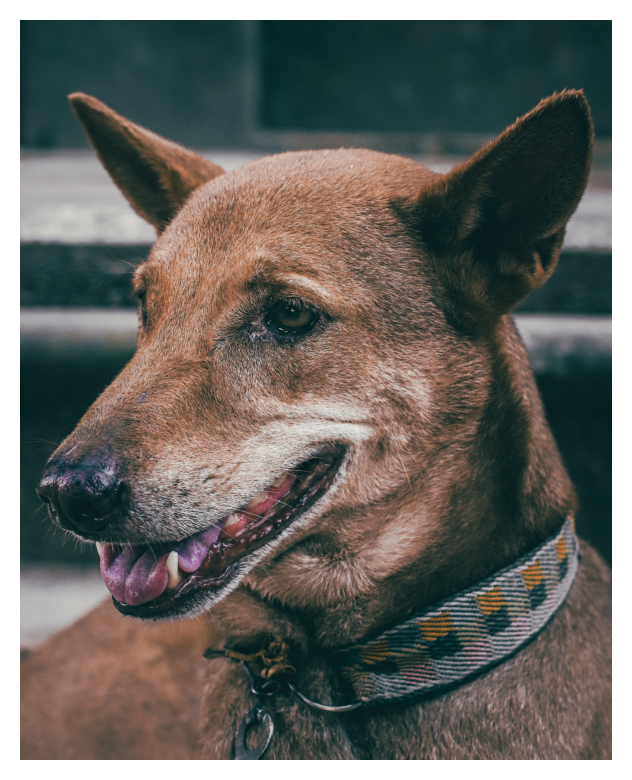

**gemini-3.1-pro-preview** &nbsp;|&nbsp; 115.0s &nbsp;|&nbsp; 719 tok

```json
{
  "polygon": [
    [0, 1000],
    [999, 1000],
    [999, 810],
    [989, 765],
    [957, 720],
    [925, 680],
    [885, 597],
    [844, 521],
    [807, 451],
    [806, 396],
    [831, 350],
    [887, 307],
    [923, 222],
    [963, 129],
    [946, 92],
    [889, 87],
    [824, 101],
    [765, 126],
    [691, 195],
    [630, 203],
    [567, 187],
    [470, 167],
    [359, 176],
    [289, 192],
    [236, 172],
    [173, 151],
    [106, 97],
    [90, 105],
    [105, 121],
    [138, 164],
    [159, 219],
    [191, 310],
    [193, 375],
    [168, 451],
    [116, 521],
    [57, 588],
    [25, 624],
    [34, 659],
    [76, 706],
    [121, 783],
    [138, 793],
    [160, 792],
    [175, 810],
    [200, 809],
    [230, 807],
    [250, 800],
    [273, 792],
    [250, 820],
    [220, 840],
    [190, 850],
    [170, 830],
    [150, 810],
    [130, 792],
    [112, 795],
    [90, 805],
    [68, 822],
    [43, 839],
    [22, 856],
    [0, 874]
  ],
  "label": "animal"
}
```

**gemini-3.1-flash-lite-preview** &nbsp;|&nbsp; 5.6s &nbsp;|&nbsp; 246 tok

{"polygon": [[240, 93], [352, 70], [440, 83], [540, 80], [709, 87], [857, 102], [966, 114], [946, 278], [913, 401], [931, 575], [973, 762], [973, 908], [829, 935], [568, 939], [437, 959], [299, 974], [260, 900], [288, 773], [291, 642], [236, 520], [179, 442], [146, 335], [177, 219], [228, 112]] , "label": "main animal"}

**gemma-4-31b-it** &nbsp;|&nbsp; 66.2s &nbsp;|&nbsp; 345 tok

```json
{"polygon": [[88, 101], [150, 140], [240, 220], [330, 170], [460, 160], [580, 180], [680, 120], [800, 80], [920, 80], [960, 120], [960, 240], [930, 320], [860, 390], [820, 520], [860, 650], [910, 750], [930, 850], [910, 950], [820, 980], [650, 995], [450, 998], [250, 980], [80, 930], [20, 860], [120, 770], [150, 680], [60, 630], [30, 580], [50, 530], [120, 490], [220, 420], [240, 330], [200, 240], [88, 101]], "label": "dog"}
```

**gemma-4-26b-a4b-it** &nbsp;|&nbsp; 31.6s &nbsp;|&nbsp; 262 tok

```json
{"polygon": [[100, 123], [247, 244], [343, 338], [194, 473], [39, 585], [42, 644], [101, 689], [169, 733], [248, 786], [342, 807], [355, 852], [380, 913], [451, 962], [566, 997], [997, 997], [997, 822], [917, 691], [967, 150], [963, 100], [872, 112], [816, 186], [745, 206], [632, 198], [448, 193], [265, 148]], "label": "dog"}
```


⏱ Wall: 115.0s (parallel) vs 218.4s (sequential would be)


In [55]:
seg_img = Image.open('happy-doggy.jpg')

results_seg = compare(
    """Segment the main animal in this image.
Return JSON: {"polygon": [[x1,y1], [x2,y2], ...], "label": "..."}
Coordinates in [0, 1000] range. Use 20+ points.
Return ONLY valid JSON.""",
    images=[seg_img],
)

In [ ]:
from matplotlib.patches import Polygon as MPLPoly

img_np = np.array(seg_img); h, w = img_np.shape[:2]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, model in zip(axes.flat, MODELS):
    ax.set_title(SHORT[model], fontsize=10); ax.imshow(img_np)
    try:
        raw = results_seg[model]['response'].strip()
        raw = re.sub(r'```json\s*', '', raw)
        raw = re.sub(r'```', '', raw)
        m = re.search(r'\{.*\}', raw, re.DOTALL)
        seg = json.loads(m.group() if m else raw)
        pts_raw = seg.get('polygon') or seg.get('segmentation') or seg.get('points', [])
        pts = [(x*w/1000, y*h/1000) for x, y in pts_raw]
        ax.add_patch(MPLPoly(pts, closed=True, fill=True, fc='red', alpha=0.35, ec='red', lw=2))
        ax.set_xlabel(f"{len(pts)} pts \u2014 {seg.get('label','?')}")
    except:
        ax.set_xlabel("parse error")
    ax.axis('off')
plt.suptitle("Segmentation", fontsize=14); plt.tight_layout(); plt.show()

## Task 4: Object Detection

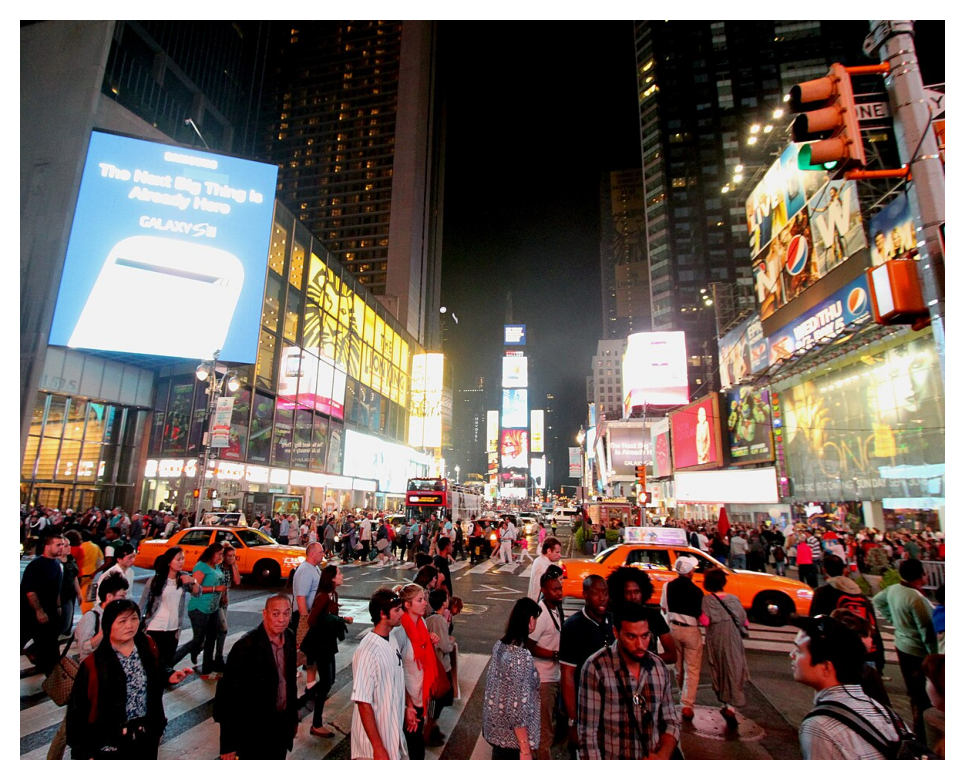

**gemini-3.1-pro-preview** &nbsp;|&nbsp; 10.7s &nbsp;|&nbsp; 1087 tok

```json
[
  {"box_2d": [785, 590, 999, 725], "label": "person"},
  {"box_2d": [781, 51, 998, 163], "label": "person"},
  {"box_2d": [693, 2, 903, 56], "label": "person"},
  {"box_2d": [798, 829, 997, 960], "label": "person"},
  {"box_2d": [773, 214, 998, 303], "label": "person"},
  {"box_2d": [763, 357, 997, 431], "label": "person"},
  {"box_2d": [712, 131, 893, 185], "label": "person"},
  {"box_2d": [781, 497, 1000, 569], "label": "person"},
  {"box_2d": [748, 582, 996, 646], "label": "person"},
  {"box_2d": [757, 403, 998, 459], "label": "person"},
  {"box_2d": [735, 301, 971, 353], "label": "person"},
  {"box_2d": [705, 182, 882, 230], "label": "person"},
  {"box_2d": [725, 687, 946, 746], "label": "person"},
  {"box_2d": [740, 729, 959, 794], "label": "person"},
  {"box_2d": [725, 924, 988, 997], "label": "person"},
  {"box_2d": [737, 549, 994, 596], "label": "person"},
  {"box_2d": [704, 292, 897, 331], "label": "person"},
  {"box_2d": [695, 547, 786, 588], "label": "person"},
  {"box_2d": [710, 77, 804, 126], "label": "person"},
  {"box_2d": [716, 856, 929, 943], "label": "person"},
  {"box_2d": [691, 836, 770, 862], "label": "person"},
  {"box_2d": [763, 437, 973, 477], "label": "person"},
  {"box_2d": [693, 36, 833, 67], "label": "person"},
  {"box_2d": [744, 75, 843, 118], "label": "person"},
  {"box_2d": [672, 514, 736, 538], "label": "person"},
  {"box_2d": [689, 52, 798, 88], "label": "person"},
  {"box_2d": [664, 383, 736, 409], "label": "person"},
  {"box_2d": [670, 417, 735, 439], "label": "person"},
  {"box_2d": [699, 442, 791, 472], "label": "person"},
  {"box_2d": [734, 424, 788, 458], "label": "person"},
  {"box_2d": [665, 345, 732, 367], "label": "person"},
  {"box_2d": [682, 764, 740, 792], "label": "person"}
]
```

**gemini-3.1-flash-lite-preview** &nbsp;|&nbsp; 3.5s &nbsp;|&nbsp; 362 tok

[{"point": [840, 965], "label": "person"}, {"point": [898, 882], "label": "person"}, {"point": [763, 755], "label": "person"}, {"point": [763, 720], "label": "person"}, {"point": [735, 665], "label": "person"}, {"point": [785, 608], "label": "person"}, {"point": [730, 575], "label": "person"}, {"point": [830, 545], "label": "person"}, {"point": [863, 672], "label": "person"}, {"point": [858, 435], "label": "person"}, {"point": [805, 462], "label": "person"}, {"point": [850, 397], "label": "person"}, {"point": [790, 332], "label": "person"}, {"point": [738, 307], "label": "person"}, {"point": [763, 208], "label": "person"}, {"point": [773, 172], "label": "person"}, {"point": [883, 117], "label": "person"}, {"point": [735, 111], "label": "person"}, {"point": [758, 45], "label": "person"}]

**gemma-4-31b-it** &nbsp;|&nbsp; 93.9s &nbsp;|&nbsp; 956 tok

```json
[
  {"box_2d": [701, 0, 886, 59], "label": "person"},
  {"box_2d": [780, 48, 998, 154], "label": "person"},
  {"box_2d": [701, 61, 831, 110], "label": "person"},
  {"box_2d": [687, 111, 786, 151], "label": "person"},
  {"box_2d": [710, 133, 856, 174], "label": "person"},
  {"box_2d": [724, 163, 894, 216], "label": "person"},
  {"box_2d": [764, 210, 998, 297], "label": "person"},
  {"box_2d": [683, 242, 765, 281], "label": "person"},
  {"box_2d": [683, 282, 765, 321], "label": "person"},
  {"box_2d": [708, 309, 786, 346], "label": "person"},
  {"box_2d": [708, 343, 783, 375], "label": "person"},
  {"box_2d": [718, 372, 788, 406], "label": "person"},
  {"box_2d": [803, 353, 998, 418], "label": "person"},
  {"box_2d": [782, 387, 998, 445], "label": "person"},
  {"box_2d": [706, 401, 786, 442], "label": "person"},
  {"box_2d": [686, 441, 770, 481], "label": "person"},
  {"box_2d": [743, 451, 889, 502], "label": "person"},
  {"box_2d": [681, 481, 761, 516], "label": "person"},
  {"box_2d": [802, 486, 998, 560], "label": "person"},
  {"box_2d": [695, 510, 768, 544], "label": "person"},
  {"box_2d": [678, 538, 758, 573], "label": "person"},
  {"box_2d": [732, 547, 921, 602], "label": "person"},
  {"box_2d": [792, 594, 998, 707], "label": "person"},
  {"box_2d": [704, 678, 788, 721], "label": "person"},
  {"box_2d": [765, 711, 967, 783], "label": "person"},
  {"box_2d": [812, 834, 998, 958], "label": "person"},
  {"box_2d": [748, 931, 910, 986], "label": "person"},
  {"box_2d": [765, 970, 915, 1000], "label": "person"}
]
```

**gemma-4-26b-a4b-it** &nbsp;|&nbsp; 83.2s &nbsp;|&nbsp; 1437 tok

```json
[
  {"box_2d": [776, 44, 1000, 166], "label": "person"},
  {"box_2d": [774, 210, 1000, 320], "label": "person"},
  {"box_2d": [767, 353, 1000, 424], "label": "person"},
  {"box_2d": [772, 483, 1000, 574], "label": "person"},
  {"box_2d": [759, 596, 1000, 714], "label": "person"},
  {"box_2d": [736, 712, 987, 793], "label": "person"},
  {"box_2d": [814, 836, 1000, 974], "label": "person"},
  {"box_2d": [732, 932, 916, 998], "label": "person"},
  {"box_2d": [703, 178, 887, 238], "label": "person"},
  {"box_2d": [695, 0, 892, 68], "label": "person"},
  {"box_2d": [690, 37, 852, 104], "label": "person"},
  {"box_2d": [741, 556, 945, 617], "label": "person"},
  {"box_2d": [710, 453, 850, 500], "label": "person"},
  {"box_2d": [684, 302, 788, 341], "label": "person"},
  {"box_2d": [692, 526, 794, 570], "label": "person"},
  {"box_2d": [708, 403, 836, 446], "label": "person"},
  {"box_2d": [684, 564, 794, 609], "label": "person"},
  {"box_2d": [697, 342, 799, 383], "label": "person"},
  {"box_2d": [695, 417, 794, 457], "label": "person"},
  {"box_2d": [684, 282, 783, 317], "label": "person"},
  {"box_2d": [684, 480, 783, 517], "label": "person"},
  {"box_2d": [681, 101, 774, 144], "label": "person"},
  {"box_2d": [688, 144, 772, 181], "label": "person"},
  {"box_2d": [684, 238, 765, 275], "label": "person"},
  {"box_2d": [681, 264, 763, 300], "label": "person"},
  {"box_2d": [673, 436, 763, 474], "label": "person"},
  {"box_2d": [673, 504, 774, 543], "label": "person"},
  {"box_2d": [684, 604, 757, 640], "label": "person"},
  {"box_2d": [684, 679, 748, 714], "label": "person"},
  {"box_2d": [681, 726, 741, 761], "label": "person"},
  {"box_2d": [684, 770, 737, 807], "label": "person"},
  {"box_2d": [684, 813, 737, 844], "label": "person"},
  {"box_2d": [677, 854, 741, 889], "label": "person"},
  {"box_2d": [681, 884, 741, 918], "label": "person"},
  {"box_2d": [681, 913, 741, 947], "label": "person"},
  {"box_2d": [681, 963, 750, 998], "label": "person"},
  {"box_2
*[truncated]*


⏱ Wall: 94.0s (parallel) vs 191.4s (sequential would be)


In [57]:
detect_img = Image.open('crowd2.jpg')

results_detect = compare(
    """Detect all people in this image.
Return a JSON array: [{"label": "person", "box_2d": [y_min, x_min, y_max, x_max]}]
Coordinates in [0, 1000] range.
Return ONLY the JSON array, no explanation.""",
    images=[detect_img],
)

In [ ]:
img_np = np.array(detect_img); h, w = img_np.shape[:2]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, model in zip(axes.flat, MODELS):
    ax.set_title(SHORT[model], fontsize=10)
    resp = results_detect[model]['response'].strip()
    resp = re.sub(r'```json\s*', '', resp)
    resp = re.sub(r'```', '', resp)
    try:
        m = re.search(r'\[.*\]', resp, re.DOTALL)
        dets = json.loads(m.group() if m else resp)
        pil = Image.fromarray(img_np.copy())
        draw = ImageDraw.Draw(pil)
        n_drawn = 0
        for d in dets:
            if not isinstance(d, dict):
                continue
            box = d.get('box') or d.get('bbox') or d.get('box_2d') or d.get('bounding_box')
            if box and len(box) == 4:
                y1, x1, y2, x2 = box
                draw.rectangle([x1*w/1000, y1*h/1000, x2*w/1000, y2*h/1000], outline='lime', width=2)
                n_drawn += 1
            elif 'point' in d and isinstance(d.get('point'), list) and len(d['point']) == 2:
                py, px = d['point']
                cx, cy = px*w/1000, py*h/1000
                draw.ellipse([cx-10, cy-10, cx+10, cy+10], outline='lime', width=2)
                n_drawn += 1
        ax.imshow(np.array(pil))
        ax.set_xlabel(f"{n_drawn} detections")
    except Exception as e:
        ax.imshow(img_np)
        ax.set_xlabel("parse error")
    ax.axis('off')
plt.suptitle("Object Detection: People", fontsize=14); plt.tight_layout(); plt.show()

## Task 5: Change Detection

Two images of the same area — what changed? This tests multi-image reasoning. Note: some models may struggle with multiple images in a single prompt.

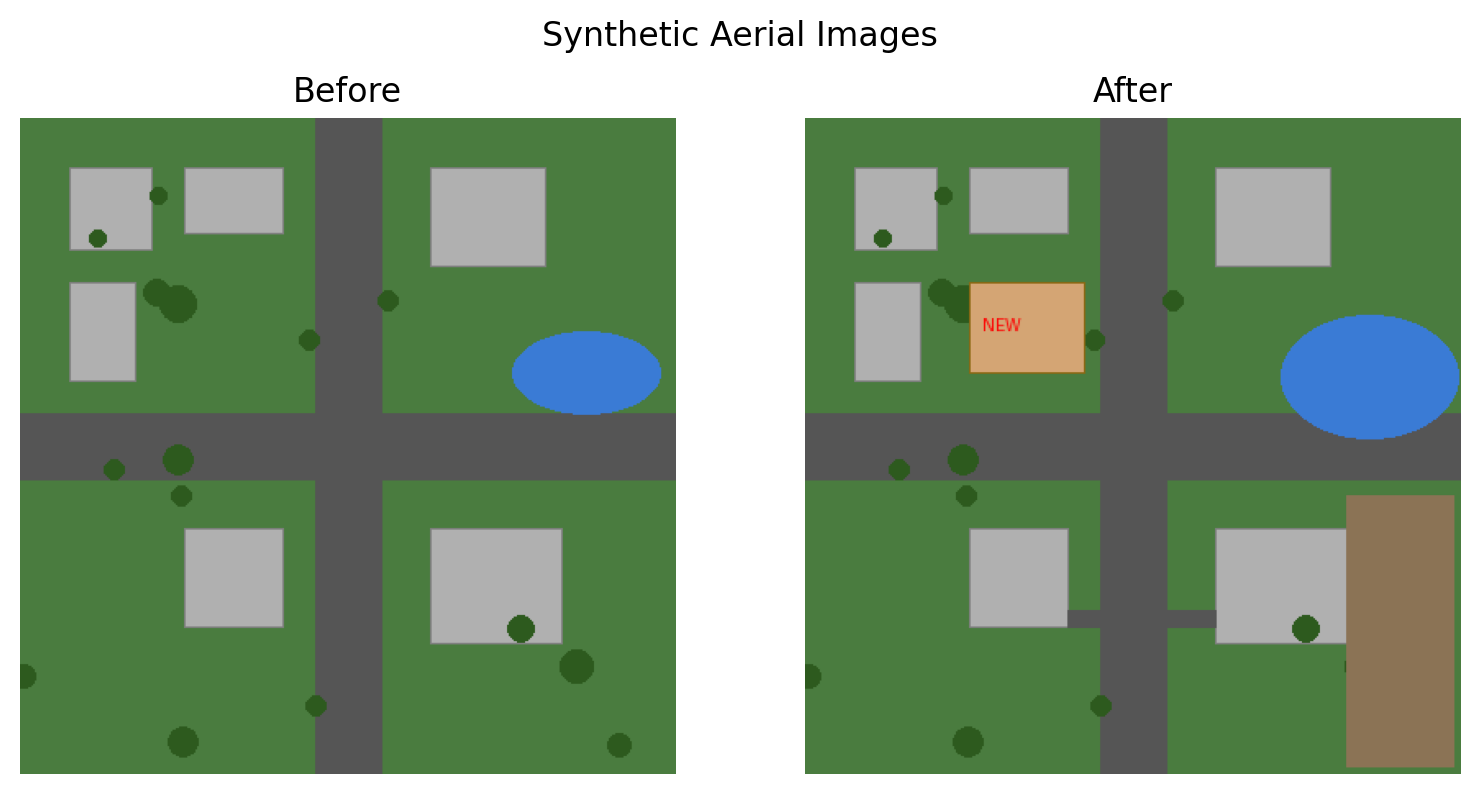

In [59]:
# Synthetic before/after aerial images
np.random.seed(123)
S = 400

def make_aerial():
    img = Image.new('RGB', (S, S), '#4a7c3f')
    d = ImageDraw.Draw(img)
    d.rectangle([180, 0, 220, S], fill='#555')  # vertical road
    d.rectangle([0, 180, S, 220], fill='#555')  # horizontal road
    for b in [(30,30,80,80),(100,30,160,70),(30,100,70,160),
              (250,30,320,90),(250,250,330,320),(100,250,160,310)]:
        d.rectangle(b, fill='#b0b0b0', outline='#808080')
    for _ in range(15):
        x, y = np.random.randint(0, S, 2)
        r = np.random.randint(5, 12)
        d.ellipse([x-r, y-r, x+r, y+r], fill='#2d5a1e')
    d.ellipse([300, 130, 390, 180], fill='#3a7bd5')  # pond
    return img

before = make_aerial()
after = before.copy()
d = ImageDraw.Draw(after)
d.rectangle([100, 100, 170, 155], fill='#d4a574', outline='#8b6914')  # new building
d.text((108, 120), "NEW", fill='red')
d.rectangle([330, 230, 395, 395], fill='#8b7355')  # deforestation
d.ellipse([290, 120, 398, 195], fill='#3a7bd5')  # expanded water
d.rectangle([160, 300, 250, 310], fill='#555')  # new road

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(before); ax1.set_title('Before'); ax1.axis('off')
ax2.imshow(after); ax2.set_title('After'); ax2.axis('off')
plt.suptitle('Synthetic Aerial Images'); plt.tight_layout(); plt.show()

In [60]:
results_change = compare(
    """These are 'before' (first) and 'after' (second) aerial images of the same area.
List every change you detect. For each change specify:
- What changed (added/removed/modified)
- Where (use quadrant: top-left, center, bottom-right, etc.)
Bullet points only, be specific.""",
    images=[before, after],
    display_images=False,
)

**gemini-3.1-pro-preview** &nbsp;|&nbsp; 41.4s &nbsp;|&nbsp; 159 tok

Based on a comparison of the two images, here are the changes detected:

*   **Added**: An orange rectangular building labeled "NEW" in the top-left quadrant.
*   **Modified**: The blue pond shifted downwards and now overlaps the horizontal road in the top-right quadrant.
*   **Added**: A grey driveway connecting the square building to the vertical road in the bottom-left quadrant.
*   **Added**: A grey driveway connecting the square building to the vertical road in the bottom-right quadrant.
*   **Added**: A large brown rectangular building on the right side of the bottom-right quadrant.
*   **Modified**: A tree shifted position from below the square building to overlapping its bottom-right corner in the bottom-right quadrant.

**gemini-3.1-flash-lite-preview** &nbsp;|&nbsp; 3.2s &nbsp;|&nbsp; 60 tok

Here are the changes detected between the two images:

*   **Top-left quadrant:** Added a new rectangular building labeled "NEW" in an orange-tan color.
*   **Bottom-right quadrant:** Added a large, rectangular brown building on the far right edge of the frame.

**gemma-4-31b-it** &nbsp;|&nbsp; 14.6s &nbsp;|&nbsp; 25 tok

* Added orange rectangle with "NEW" text in center-left.
* Added brown rectangular area in bottom-right.

**gemma-4-26b-a4b-it** &nbsp;|&nbsp; 82.3s &nbsp;|&nbsp; 34 tok

I only see one image provided in your message. To perform the comparison and list the changes as requested, please provide both the "before" and "after" images.


⏱ Wall: 82.3s (parallel) vs 141.5s (sequential would be)


## Task 6: Structured JSON Extraction

Gemini supports `response_schema` for guaranteed valid JSON. Gemma needs prompt-based extraction — does it still produce valid JSON?

In [ ]:
bus_img = Image.open('bus.jpg')

schema_config = types.GenerateContentConfig(
    response_mime_type="application/json",
    response_schema={
        "type": "OBJECT",
        "properties": {
            "scene": {"type": "STRING"},
            "people_count": {"type": "INTEGER"},
            "text_visible": {"type": "ARRAY", "items": {"type": "STRING"}},
        },
        "required": ["scene", "people_count", "text_visible"],
    },
)

prompt_base = "Describe this scene. How many people? What text is visible?"
prompt_gemma = prompt_base + '\nReturn ONLY valid JSON: {"scene": "...", "people_count": int, "text_visible": ["..."]}'

async def _json_task():
    tasks = []
    for m in MODELS:
        if 'gemma' in m:
            tasks.append(_call_one(m, [bus_img, prompt_gemma]))
        else:
            tasks.append(_call_one(m, [bus_img, prompt_base], config=schema_config))
    return dict(await asyncio.gather(*tasks))

try:
    loop = asyncio.get_running_loop()
    import nest_asyncio; nest_asyncio.apply()
    results_json = loop.run_until_complete(_json_task())
except RuntimeError:
    results_json = asyncio.run(_json_task())

fig, ax = plt.subplots(figsize=(3, 4))
ax.imshow(bus_img); ax.axis('off'); plt.tight_layout(); plt.show()

for model, r in results_json.items():
    display(Markdown(f"**{SHORT[model]}** ({r['time']})"))
    try:
        raw = r['response'].strip()
        raw = re.sub(r'```json\s*', '', raw)
        raw = re.sub(r'```', '', raw)
        parsed = json.loads(raw)
        print(json.dumps(parsed, indent=2))
    except:
        print(f"[Invalid JSON] {r['response'][:200]}")

## Summary: Time & Tokens

In [62]:
all_tasks = {
    "Scene": results_scene,
    "Chart": results_chart,
    "Segment": results_seg,
    "Detect": results_detect,
    "Change": results_change,
    "JSON": results_json,
}

rows = []
for task, results in all_tasks.items():
    for model, r in results.items():
        in_t = r["in_tok"] if isinstance(r["in_tok"], int) else 0
        out_t = r["out_tok"] if isinstance(r["out_tok"], int) else 0
        rows.append({
            "Task": task, "Model": SHORT[model],
            "Time": r["time"], "In Tok": in_t, "Out Tok": out_t,
        })

df = pd.DataFrame(rows)

display(Markdown("### Response Time"))
display(df.pivot(index="Task", columns="Model", values="Time").rename_axis(None, axis=1))

display(Markdown("### Output Tokens"))
display(df.pivot(index="Task", columns="Model", values="Out Tok").rename_axis(None, axis=1))

### Response Time

,gemini-3.1-flash-lite-preview,gemini-3.1-pro-preview,gemma-4-26b-a4b-it,gemma-4-31b-it
Task,,,,
Change,3.2s,41.4s,82.3s,14.6s
Chart,3.6s,11.7s,29.6s,15.1s
Detect,3.5s,10.7s,83.2s,93.9s
JSON,2.6s,3.6s,12.8s,27.5s
Scene,3.0s,10.8s,16.8s,12.2s
Segment,5.6s,115.0s,31.6s,66.2s


### Output Tokens

,gemini-3.1-flash-lite-preview,gemini-3.1-pro-preview,gemma-4-26b-a4b-it,gemma-4-31b-it
Task,,,,
Change,60,159,34,25
Chart,197,116,117,86
Detect,362,1087,1437,956
JSON,114,54,72,73
Scene,48,64,53,43
Segment,246,719,262,345


In [ ]:
# Aggregate per model
agg = df.groupby('Model').agg(
    Total_Input_Tokens=('In Tok', 'sum'),
    Total_Output_Tokens=('Out Tok', 'sum'),
    Total_Time_s=('Time', lambda x: sum(float(t.replace('s','').replace('err','0')) for t in x)),
).round(0)
agg['Total_Time_s'] = agg['Total_Time_s'].apply(lambda x: f"{x:.1f}s")

display(Markdown("### Aggregate per Model"))
display(agg)

# Bar chart of time and tokens
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#4285f4', '#34a853', '#ea4335', '#fbbc04']

time_vals = df.groupby('Model')['Time'].apply(
    lambda x: sum(float(t.replace('s','').replace('err','0')) for t in x)
)
time_vals.plot.bar(ax=ax1, color=colors)
ax1.set_ylabel('Time (s)'); ax1.set_title('Total Time per Model')
ax1.tick_params(axis='x', rotation=30, labelsize=8)
for i, v in enumerate(time_vals):
    ax1.text(i, v + max(time_vals)*0.02, f'{v:.0f}s', ha='center', fontsize=9)

tok_vals = df.groupby('Model')['Out Tok'].sum()
tok_vals.plot.bar(ax=ax2, color=colors)
ax2.set_ylabel('Tokens'); ax2.set_title('Total Output Tokens per Model')
ax2.tick_params(axis='x', rotation=30, labelsize=8)
for i, v in enumerate(tok_vals):
    ax2.text(i, v + max(tok_vals)*0.02, f'{v:,.0f}', ha='center', fontsize=9)

plt.tight_layout(); plt.show()

## Takeaways

- **Same API, open vs closed** — `google-genai` SDK works for both; switching is just a model name change
- **Apache 2.0** — Gemma 4 can be fine-tuned and self-hosted (great for sensitive data)
- **Async is essential** — running 4 models in parallel with `client.aio` saves 3-4x wall time
- **Structured output** — Gemini supports `response_schema` for guaranteed JSON; Gemma needs prompt engineering
- **Multi-image gaps** — `gemma-4-26b-a4b-it` refused the change detection task, claiming it could only see one image. Multi-image prompts work better with Gemini and the larger Gemma model
- **Output format fragility** — models use different JSON keys for the same concept (e.g. `box` vs `box_2d` vs `bbox` for bounding boxes). Robust parsing is essential
- **Speed** — Gemini Flash Lite is ~10x faster than Gemma models on the API; Gemma models are slow (50-80s per call) likely due to serving infrastructure